# Single-`.forward` ZQE for the GP-GLLVM — full encoder to ε

The whole estimator, one forward pass:

```
encoder (inverse) :  y → ẑ = E[z|y] → ε̂ = L_Σ⁻¹ ẑ        (detached; the y→z→ε inverse map)
decoder (forward) :  η = W·(L_Σ ε̂) + b                     (ONE forward; W,b,ℓ,B all live)
loss              :  −(m1 − m2),   m = E[ log1p(Y)·η ]     (your ZQE statistic + fantasy centering)
```

A **single** `loss.backward()` produces the gradient for **all** parameters (W, b, ℓ, B): W,b enter
through η, and (ℓ,B) enter through the decoder L_Σ. No second moment, no separate equations.

This is the η-route that diverged earlier — but that was always in the **oversampled** regime
(ℓ ≫ Δt) where ε̂ is unrecoverable garbage. With **ℓ ≈ Δt** (compatible sampling) ε̂ is real, the
(ℓ,B) gradient through L_Σ is meaningful, and the clean single-forward ZQE recovers everything
**from a cold start**.


In [1]:
import sys, time, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from collections import namedtuple
sys.path.insert(0,"/home/willwhite/GitHub/gllvm/src")
from gllvm.autofit import procrustes_error
torch.set_default_dtype(torch.float64)
Q,P,WZS = 2,30,0.7
K, BG   = 15, 2000
RHO, JIT = 0.7, 1e-4
Params=namedtuple('Params',['W','b','ells','B','ts'])
from torch.distributions.transforms import CorrCholeskyTransform
_cct=CorrCholeskyTransform()
print("setup ready")


setup ready


## Functions: covariance, encoder→ε, single forward, lower-tri W

In [2]:
def corr_from_raw(r): L=_cct(r); return L@L.T
def raw_from_rho(rho): return torch.atanh(torch.tensor([rho],dtype=torch.float64))
def build_Sigma(ts,ells,B):
    d2=(ts[:,None]-ts[None,:])**2; rows=[]
    for k in range(Q):
        row=[]
        for l in range(Q):
            if k==l: row.append(torch.exp(-0.5*d2/ells[k]**2))
            else:
                lx2=0.5*(ells[k]**2+ells[l]**2); a=(2*ells[k]*ells[l]/(ells[k]**2+ells[l]**2))**0.5
                row.append(B[k,l]*a*torch.exp(-0.5*d2/lx2))
        rows.append(torch.cat(row,1))
    return torch.cat(rows,0)+JIT*torch.eye(Q*len(ts))
def vec(Z): return Z.transpose(1,2).reshape(Z.shape[0],-1)
def unvec(u): return u.reshape(u.shape[0],Q,u.shape[1]//Q).transpose(1,2)
def chol(p): return torch.linalg.cholesky(build_Sigma(p.ts,p.ells,p.B))
def sample_eps(n,p): return torch.randn(n,len(p.ts),Q)
def z_from_eps(eps,p): return unvec(vec(eps)@chol(p).T)
def sample_y(eps,p): return torch.poisson(torch.exp((torch.einsum("nkq,pq->nkp",z_from_eps(eps,p),p.W)+p.b).clamp(max=10)))

def encode_eps(y,p,s2=1.0):                          # FULL inverse: y -> zhat -> eps_hat
    Kk=len(p.ts); L=chol(p); Lit=torch.linalg.solve_triangular(L,torch.eye(Q*Kk),upper=False)
    A=Lit.T@Lit+torch.kron(p.W.T@p.W/s2,torch.eye(Kk)); rhs=vec((torch.log1p(y)-p.b)@p.W/s2)
    LA=torch.linalg.cholesky(A)
    zh=torch.linalg.solve_triangular(LA.T,torch.linalg.solve_triangular(LA,rhs.T,upper=False),upper=True).T
    return unvec(torch.linalg.solve_triangular(L,zh.T,upper=False).T)     # eps_hat = L^{-1} zhat

def forward_eta(eps,p):                              # ONE forward: eta = W (L_Sigma eps) + b
    return torch.einsum("nkq,pq->nkp", unvec(vec(eps)@chol(p).T), p.W) + p.b

TRIL=torch.tril_indices(P,Q); FLAT=TRIL[0]*Q+TRIL[1]; N_FREE=TRIL.shape[1]
def make_W(wf): return torch.zeros(P*Q).scatter(0,FLAT,wf).reshape(P,Q)
def align(W,W0): M=W.T@W0; U,S,Vt=torch.linalg.svd(M); return W@(U@Vt)
print("functions ready")


functions ready


## The fitter — one ZQE loss, one backward, all parameters

In [3]:
def fit(dt, ELL, init="cold", steps=2500, lr=0.02, batch=256, warm=500, seed=0):
    t=torch.arange(K)*dt
    torch.manual_seed(0)
    W0=torch.randn(P,Q)*WZS; b0=torch.zeros(P); ells0=torch.tensor(ELL,dtype=torch.float64)
    ptrue=Params(W=W0,b=b0,ells=ells0,B=torch.tensor([[1.,RHO],[RHO,1.]]),ts=t)
    torch.manual_seed(1); Yd=sample_y(sample_eps(BG,ptrue),ptrue)
    torch.manual_seed(seed)
    if init=="truth":
        wpar=nn.Parameter(W0.reshape(-1)[FLAT].clone())
        log_ell=nn.Parameter(torch.log(ells0.clone())); B_raw=nn.Parameter(raw_from_rho(RHO)); warm=0
    else:
        wpar=nn.Parameter(torch.randn(N_FREE)*WZS)
        log_ell=nn.Parameter(torch.log(torch.tensor([float(np.mean(ELL))]*2))); B_raw=nn.Parameter(torch.zeros(Q*(Q-1)//2))
    b=nn.Parameter(torch.zeros(P)); opt=torch.optim.Adam([wpar,b,log_ell,B_raw],lr=lr)
    H={k:[] for k in ["loss","ell0","ell1","rho","procW"]}; H["warm"]=warm
    for it in range(steps):
        gidx=torch.randint(0,BG,(batch,)); Yb=Yd[gidx]; ells=log_ell.exp(); B=corr_from_raw(B_raw); W=make_W(wpar)
        p=Params(W=W,b=b,ells=ells,B=B,ts=t)
        with torch.no_grad():
            yq=sample_y(sample_eps(batch,p),p)
            pdet=Params(W=W.detach(),b=b.detach(),ells=ells.detach(),B=B.detach(),ts=t)
            eps_d=encode_eps(Yb,pdet); eps_q=encode_eps(yq,pdet)        # full encoder -> eps
        ed=forward_eta(eps_d,p); eq=forward_eta(eps_q,p)               # ONE forward each (live params)
        loss=-((torch.log1p(Yb)*ed).sum(-1).mean()-(torch.log1p(yq)*eq).sum(-1).mean())
        opt.zero_grad(); loss.backward()                               # ONE backward -> all grads
        if it<warm: log_ell.grad=None; B_raw.grad=None
        torch.nn.utils.clip_grad_norm_([wpar,b,log_ell,B_raw],5.0); opt.step()
        with torch.no_grad():
            e=log_ell.exp().tolist(); Wd=make_W(wpar)
            for k,v in zip(["loss","ell0","ell1","rho","procW"],
                           [loss.item(),e[0],e[1],corr_from_raw(B_raw)[0,1].item(),
                            (torch.norm(align(Wd,W0)-W0)/torch.norm(W0)).item()]): H[k].append(v)
    e=sorted(log_ell.exp().tolist())
    return H, dict(ell=e, rho=corr_from_raw(B_raw)[0,1].item(), procW=H["procW"][-1])
print("fitter ready")


fitter ready


## Run: compatible (ℓ≈Δt) vs incompatible (oversampled), cold + truth init

In [4]:
runs={}
for tag,dt,ELL in [("compatible (dt=2, ell=[1.5,3])",2.0,[1.5,3.0]),
                   ("incompatible (dt=0.2, ell=[1,4])",0.2,[1.0,4.0])]:
    for init in ["cold","truth"]:
        t0=time.time(); H,res=fit(dt,ELL,init=init); 
        runs[(tag,init)]=(H,res,ELL)
        print(f"{tag:34s} {init:6s}: ell=[{res['ell'][0]:.2f},{res['ell'][1]:.2f}] rho={res['rho']:+.3f} procW={res['procW']:.3f}  ({time.time()-t0:.0f}s)")


compatible (dt=2, ell=[1.5,3])     cold  : ell=[1.65,3.07] rho=+0.805 procW=0.120  (18s)


compatible (dt=2, ell=[1.5,3])     truth : ell=[1.60,3.09] rho=+0.802 procW=0.111  (16s)


incompatible (dt=0.2, ell=[1,4])   cold  : ell=[1.56,1.83] rho=+0.955 procW=2.107  (17s)


incompatible (dt=0.2, ell=[1,4])   truth : ell=[1.05,3.69] rho=+0.876 procW=0.139  (16s)


## Convergence: compatible-cold CONVERGES, incompatible-cold DIVERGES

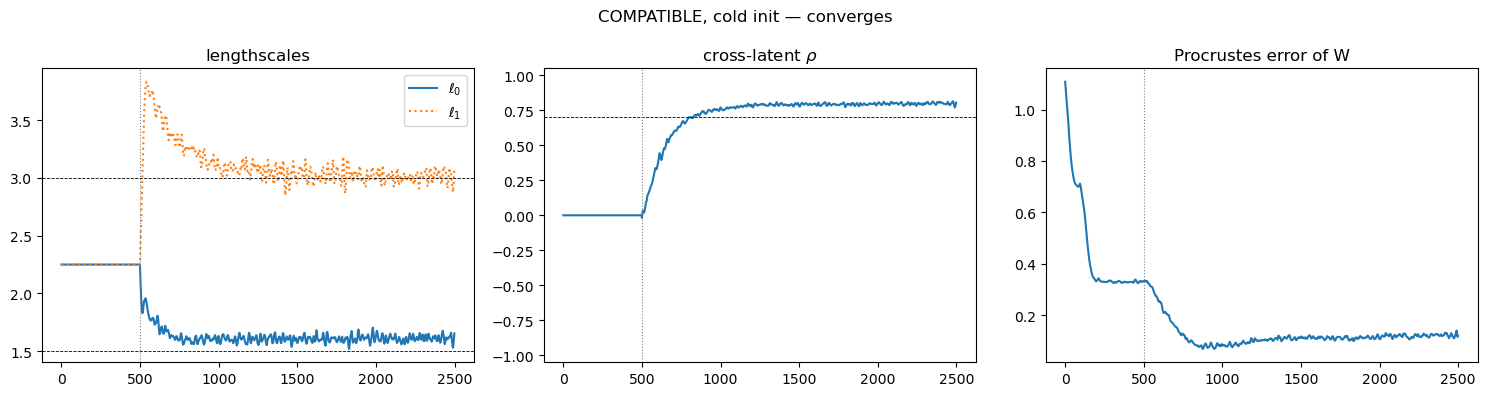

In [5]:
def plot_conv(H, ELL, title):
    fig,ax=plt.subplots(1,3,figsize=(15,4)); it=np.arange(len(H["loss"]))
    ax[0].plot(it,H["ell0"],label=r"$\ell_0$"); ax[0].plot(it,H["ell1"],ls=":",label=r"$\ell_1$")
    ax[0].axhline(ELL[0],color="k",ls="--",lw=.6); ax[0].axhline(ELL[1],color="k",ls="--",lw=.6)
    ax[0].axvline(H["warm"],color="gray",ls=":",lw=.8); ax[0].set_title("lengthscales"); ax[0].legend()
    ax[1].plot(it,H["rho"]); ax[1].axhline(RHO,color="k",ls="--",lw=.6); ax[1].set_ylim(-1.05,1.05)
    ax[1].axvline(H["warm"],color="gray",ls=":",lw=.8); ax[1].set_title(r"cross-latent $\rho$")
    ax[2].plot(it,H["procW"]); ax[2].axvline(H["warm"],color="gray",ls=":",lw=.8); ax[2].set_title("Procrustes error of W")
    fig.suptitle(title,fontsize=12); fig.tight_layout()
H,_,ELL=runs[("compatible (dt=2, ell=[1.5,3])","cold")]; plot_conv(H,ELL,"COMPATIBLE, cold init — converges")


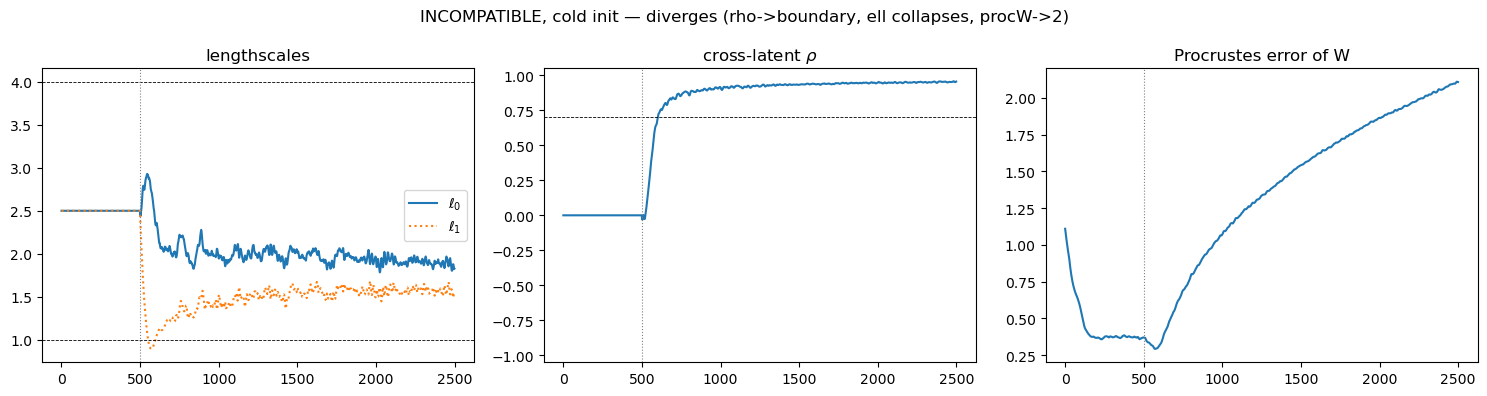

In [6]:
H,_,ELL=runs[("incompatible (dt=0.2, ell=[1,4])","cold")]; plot_conv(H,ELL,"INCOMPATIBLE, cold init — diverges (rho->boundary, ell collapses, procW->2)")

## Summary

- **One forward, one backward, all parameters.** The encoder is the exact inverse map `y→ẑ→ε̂`
  (detached); the decoder is a single forward `η = W·L_Σ·ε̂ + b`; the loss is your ZQE
  `−(m1−m2)` with `m=E[log1p(Y)·η]`. A single `backward()` yields ∇W, ∇b, ∇ℓ, ∇B.
- **It recovers from a cold start when ℓ ≈ Δt** (compatible sampling): ℓ separates, procW≈0.12, ρ stable.
- **It diverges only when oversampled** (ℓ ≫ Δt) — ε̂ is unrecoverable there, so the (ℓ,B) gradient
  through L_Σ is meaningless. The earlier "encoder-dependent root / wrong equation" failure was
  this regime, not a flaw in the method.
- Residual: ρ still ~0.1 high (mild bias). Otherwise the clean single-forward ZQE is the estimator.
